# 10 — Interpretabilidade da CNN baseline (saliency)

Mostra que a **CNN de regressão aprende física**: o gradiente |∂z/∂fluxo| (saliency) é alto
exatamente nas **linhas espectrais** que determinam o redshift.

- Fig. A: espectros individuais com a saliency e as linhas (referencial observado, deslocadas por z).
- Fig. B (chave): saliency MÉDIA no referencial de REPOUSO (de-redshift + empilha) → picos nas linhas.

Linhas — ELG: [OII], Hβ, [OIII], Hα; LRG: CaH&K, G, Mg b, Na D. (QSO ainda sem CNN.) Estilo SciencePlots.

**Nota:** zeramos a saliency no padding (sem dados) e nas bordas — senão o artefato de convolução
na borda domina e esconde as linhas (sobretudo no ELG).

In [5]:
import sys
from pathlib import Path
import numpy as np, h5py, tensorflow as tf, matplotlib.pyplot as plt

# A saliency (GradientTape) e' LEVE mas pesa na memoria da GPU; rodamos na CPU pra
# evitar OOM quando a GPU esta compartilhada com os jobs de treino.
# IMPORTANTE: se voce ja' rodou alguma celula que usou a GPU, REINICIE O KERNEL
# para esta linha ter efeito (precisa rodar antes do TF tocar na GPU).
try:
    tf.config.set_visible_devices([], 'GPU')
except Exception:
    pass

ROOT = Path.cwd()
while not (ROOT / 'config.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from config import MODELS_DIR
from src.models.cnn import PaddedSpectralCNN
from src.data import normalize_spectra
from src.evaluation.style import set_science_style
set_science_style()

OUT_DIR = ROOT / 'results' / 'interpretability'
OUT_DIR.mkdir(parents=True, exist_ok=True)

LINES = {
    'ELG': {'[OII]': 3727.4, 'Hβ': 4862.7, '[OIII]': 5008.2, 'Hα': 6564.6},
    'LRG': {'CaII K': 3934.8, 'CaII H': 3969.6, 'G': 4304.4, 'Mg b': 5175.4, 'Na D': 5892.9},
}
RANGES = {'ELG': (3500, 6800), 'LRG': (3700, 6200)}
OBJS = ['ELG', 'LRG']  # modelos cnn_baseline existentes (QSO pendente)
EDGE = 40  # pixels de borda a zerar

In [6]:
def load_obj(obj, n=400, seed=0):
    model = PaddedSpectralCNN.load(MODELS_DIR / obj / 'cnn_baseline' / 'cnn_baseline.keras').model
    with h5py.File(ROOT / f'data/processed/{obj}/{obj}spectra_padded.h5', 'r') as f:
        wave = f['wave_global'][:]
        ntot = f['ml_dataset/X_spec'].shape[0]
        idx = np.sort(np.random.default_rng(seed).choice(ntot, min(n, ntot), replace=False))
        X = f['ml_dataset/X_spec'][idx]; z = f['catalog']['redshift'][idx]
    return model, normalize_spectra(X).astype(np.float32), z, wave

def saliency(model, X, batch=32):
    """|d z_pred / d flux| por pixel, com padding e bordas zerados.

    batch pequeno (32) porque o GradientTape guarda as ativacoes -> evita estourar memoria.
    """
    nw = X.shape[1]; out = []
    for i in range(0, len(X), batch):
        xb = tf.convert_to_tensor(X[i:i+batch].reshape(-1, nw, 1))
        with tf.GradientTape() as t:
            t.watch(xb); p = model(xb)
        out.append(np.abs(t.gradient(p, xb).numpy().reshape(len(xb), nw)))
    sal = np.concatenate(out)
    sal = sal * (X != 0)              # zera padding (sem dados)
    sal[:, :EDGE] = 0; sal[:, -EDGE:] = 0  # zera bordas (artefato de convolucao)
    return sal

def smooth(a, w=9):
    return np.convolve(a, np.ones(w) / w, mode='same')

DATA = {}
for o in OBJS:
    model, X, z, wave = load_obj(o)
    DATA[o] = dict(X=X, z=z, wave=wave, sal=saliency(model, X))
    print(f'{o}: saliency {DATA[o]["sal"].shape}')

ELG: saliency (400, 4635)
LRG: saliency (400, 4674)


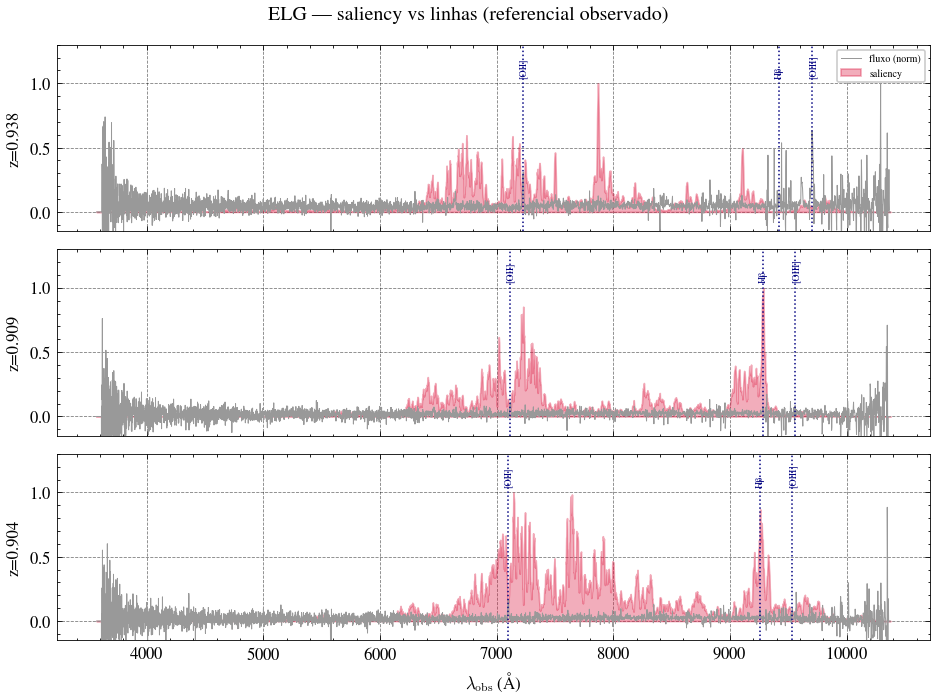

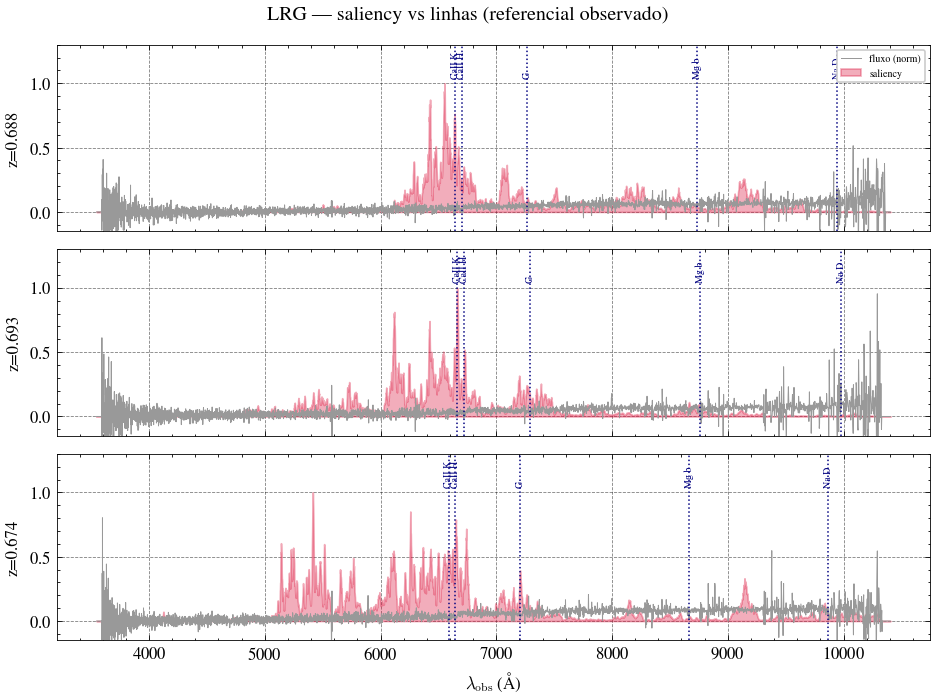

In [7]:
# Fig. A — exemplos: fluxo + saliency, linhas no referencial OBSERVADO (x(1+z))
for obj in OBJS:
    d = DATA[obj]; wave = d['wave']
    fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
    for ax, i in zip(axes, [0, 1, 2]):
        fx = d['X'][i] / (np.nanmax(np.abs(d['X'][i])) or 1)
        sl = smooth(d['sal'][i]); sl = sl / (sl.max() or 1)
        ax.plot(wave, fx, color='0.6', lw=0.6, label='fluxo (norm)')
        ax.fill_between(wave, 0, sl, color='crimson', alpha=0.35, label='saliency')
        for name, lam in LINES[obj].items():
            lo = lam * (1 + d['z'][i])
            if wave[0] < lo < wave[-1]:
                ax.axvline(lo, color='navy', ls=':', lw=0.9)
                ax.text(lo, 1.04, name, rotation=90, va='bottom', ha='center', fontsize=6, color='navy')
        ax.set_ylabel(f"z={d['z'][i]:.3f}"); ax.set_ylim(-0.15, 1.3)
    axes[0].legend(loc='upper right', fontsize=6)
    axes[-1].set_xlabel(r'$\lambda_{\mathrm{obs}}$ (Å)')
    fig.suptitle(f'{obj} — saliency vs linhas (referencial observado)')
    fig.tight_layout(); fig.savefig(OUT_DIR / f'saliency_examples_{obj}.png'); plt.show()

/tmp/ipykernel_48690/548752350.py:9: RuntimeWarning: Mean of empty slice
  return grid, np.nanmean(stack, axis=0)


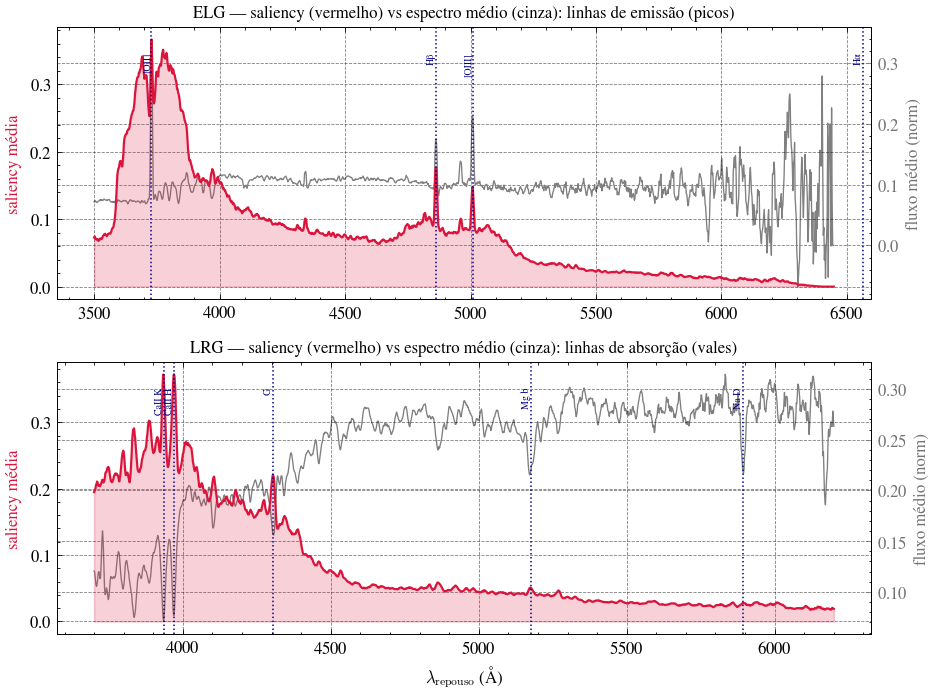

In [8]:
# Fig. B (CHAVE) — saliency MEDIA + ESPECTRO MEDIO, ambos no referencial de REPOUSO.
# Mostra que a saliency pica nas LINHAS: vales de absorcao (LRG) e picos de emissao (ELG).
def rest_mean(obj, arr, w=9):
    d = DATA[obj]; wave = d['wave']; rmin, rmax = RANGES[obj]
    grid = np.linspace(rmin, rmax, 1500); stack = []
    for i in range(len(arr)):
        s = smooth(arr[i], w); mx = np.nanmax(np.abs(s)); s = s / mx if mx > 0 else s
        stack.append(np.interp(grid, wave / (1 + d['z'][i]), s, left=np.nan, right=np.nan))
    return grid, np.nanmean(stack, axis=0)

fig, axes = plt.subplots(len(OBJS), 1, figsize=(8, 3.0 * len(OBJS)))
for ax, obj in zip(np.atleast_1d(axes), OBJS):
    d = DATA[obj]
    grid, msal = rest_mean(obj, d['sal'])
    _, mflux = rest_mean(obj, d['X'])
    # espectro medio no eixo gemeo (cinza, atras)
    ax2 = ax.twinx()
    ax2.plot(grid, mflux, color='0.5', lw=0.8)
    ax2.set_ylabel('fluxo médio (norm)', color='0.45'); ax2.tick_params(axis='y', colors='0.45')
    # saliency na frente (vermelho)
    ax.plot(grid, msal, color='crimson', lw=1.3)
    ax.fill_between(grid, 0, msal, color='crimson', alpha=0.2)
    ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
    for name, lam in LINES[obj].items():
        if grid[0] < lam < grid[-1]:
            ax.axvline(lam, color='navy', ls=':', lw=0.9)
            ax.text(lam, np.nanmax(msal) * 0.95, name, rotation=90, va='top', ha='right', fontsize=6, color='navy')
    tipo = 'emissão (picos)' if obj == 'ELG' else 'absorção (vales)'
    ax.set_title(f'{obj} — saliency (vermelho) vs espectro médio (cinza): linhas de {tipo}')
    ax.set_ylabel('saliency média', color='crimson')
axes[-1].set_xlabel(r'$\lambda_{\mathrm{repouso}}$ (Å)')
fig.tight_layout(); fig.savefig(OUT_DIR / 'saliency_restframe_mean.png'); plt.show()

**Leitura:** na Fig. B os picos da saliency média (repouso) coincidem com as linhas marcadas — ELG em
[OII]/Hβ/[OIII], LRG em CaH&K/G — ou seja, a CNN de regressão **aprendeu a usar as linhas físicas** para
estimar o redshift, sem nunca receber a posição delas. É o análogo, para a regressão, do heatmap explícito
do linedet. Figuras em `results/interpretability/`. Extensões: SmoothGrad / Grad-CAM 1D.